## Module 3: Fibrosis

## Team Members: Roy Chen and Will Marschall

## Project Title: Predicting Lung Fibrosis Severity Across Biopsy Depth Using Image Analysis and Interpolation




## Project Goal:
This project seeks to develop a Python-based image-analysis pipeline that quantifies fibrosis in black-and-white mouse lung sections by measuring the percent of white pixels at known depths into the lung, and then uses interpolation to estimate fibrosis severity at depths where a direct image measurement is not available.

## Disease Background: 
*Fill in information and please note that this module is truncated and only has 5 bullets (instead of the 11 that you did for Module #1).*

* Prevalence & incidence
* Risk factors (genetic, lifestyle)
* Symptoms
* Standard of care treatment(s)
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology)

## Data-Set: 
*Describe the data set(s) you will analyze. Cite the source(s) of the data -- in this case, these data have not yet been published and they are "hot off the press", having been recently generated by the Peirce-Cottler Lab in collaboration with the Kim Lab (https://uvahealth.com/findadoctor/John-Kim-1407155682) in the Division of Pulmonary and Critical Care at UVA. So the proper way to cite these data is:

"Unpublished data was collected by the Peirce-Cottler Lab (Dept. of Biomedical Engineering) and Kim Lab (Division of Pulmonary and Critical Care) at the University of Virginia School of Medicine. 

Also, since we covered this in Lecture 1 of this Module in detail, describe how the data was collected -- What techniques were used? What units are the data measured in? Etc.*

## Data Analysis

### 2a. Methods

For the data analysis portion of this project, we used Python to analyze a selected subset of black-and-white mouse lung images collected at known depths into a fibrotic lung. Following the workflow from lecture and the provided `main_example.py`, each image was read in grayscale, thresholded at a pixel value of 127 to create a binary image, and then used to count white and black pixels. In these processed images, white pixels were treated as a proxy for fibrotic lesion area and black pixels were treated as healthy lung tissue.

For each image, we calculated the fibrosis proxy as the percent of white pixels in the image:

$$
\text{Percent white pixels} = 100 \cdot \frac{\text{white pixels}}{\text{total pixels}}.
$$

We then wrote the analyzed image data to a `.csv` file, plotted measured percent white pixels versus depth into the lung, and used both linear and quadratic interpolation to estimate the fibrosis proxy at an unmeasured depth of 345 $\mu\text{m}$. To stay consistent with lecture and `interpolation_example.py`, we also compared the built-in SciPy interpolation methods to manual matrix-based polynomial interpolation.

In [1]:
# The following code is ran from our 'main.py' file, which contains the main logic for our fibrosis analysis. You can run this code to execute the full analysis pipeline, or you can run individual cells to test specific functions or steps in the process.
# Our full code commenting and logic is in 'main.py'

# This cell sets up our environment and imports necessary libraries and functions. It also defines the target depth for our analysis, which is 345 micrometers in this case.
from pathlib import Path
import sys
import importlib
import pandas as pd
from IPython.display import display

# Set pandas to display floats with 6 decimal places for better readability in our results.
pd.options.display.float_format = "{:.6f}".format

# Define paths to our project root and code directory, and ensure that the code directory is in our system path for imports.
PROJECT_ROOT = Path.cwd()
CODE_DIR = PROJECT_ROOT / "code"

# If the code directory is not already in the system path, add it so we can import our main module.
if str(CODE_DIR) not in sys.path:
    sys.path.append(str(CODE_DIR))

# Import our main module, which contains all the functions and logic for our analysis. We also reload it to ensure we have the latest version after any edits.
import main
importlib.reload(main)

# Define the target depth in micrometers for our analysis. This is the depth at which we will be evaluating our fibrosis predictions and measurements.
TARGET_DEPTH_UM = 345.0

### 2b. Analyze the selected images and create the measured data table

We first analyzed the selected images in the `chosen images` folder, matched each image to its recorded depth using the provided filename-depth spreadsheet, counted white and black pixels, and saved the resulting dataset to the `results` folder as a `.csv` file. The table below is the measured dataset used for the interpolation steps that follow.

In [2]:
# Now we run the main analysis pipeline, which builds our analysis table and saves it to a CSV file. 
# The analysis table contains all the relevant data and metrics for our fibrosis analysis at the target depth.
analysis_df = main.build_analysis_table()
main.save_analysis_table(analysis_df)

# Finally, we create a display DataFrame that contains only the relevant columns for our final results, and we display it in a readable format.
display_df = analysis_df[
    ["basename", "depth_um", "white_pixels", "black_pixels", "percent_white_pixels"]
].copy()

# Display the final results in a readable format.
display(display_df)

Saved analysis table to: E:\OneDrive - University of Virginia\Will M\Undergraduate Research Courses-Grants\05_Spring_2026\Computational_Biomedical_BME_2315\Module-3-Fibrosis\results\Percent_White_Pixels.csv


,basename,depth_um,white_pixels,black_pixels,percent_white_pixels
0,MASK_Sk658 Llobe ch010036.jpg,55.000000,29677,4164627,0.707555
1,MASK_SK658 Slobe ch010156.jpg,330.000000,38068,4156236,0.907612
2,MASK_SK658 Slobe ch010157.jpg,750.000000,56419,4137885,1.345134
3,MASK_SK658 Slobe ch010159.jpg,860.000000,59426,4134878,1.416826
4,MASK_SK658 Slobe ch010158.jpg,920.000000,59788,4134516,1.425457
5,MASK_SK658 Slobe ch010146.jpg,2000.000000,62913,4131391,1.499963
6,MASK_SK658 Slobe ch010143.jpg,2600.000000,70715,4123589,1.685977
7,MASK_SK658 Slobe ch010147.jpg,3000.000000,80534,4113770,1.920080
8,MASK_Sk658 Llobe ch010174.jpg,3100.000000,81014,4113290,1.931524
9,MASK_SK658 Slobe ch010149.jpg,3350.000000,83416,4110888,1.988792


The selected images spanned depths from 55 $\mu\text{m}$ to 9900 $\mu\text{m}$. Across this subset, the measured fibrosis proxy ranged from **0.707555% white pixels** at **55 $\mu\text{m}$** to approximately **5.66-5.78% white pixels** at **9900 $\mu\text{m}$**. These measured values formed the dataset used for plotting and interpolation.

### 2c. Plot measured fibrosis proxy versus lung depth

Next, we plotted the measured percent white pixels against depth into the lung. This figure shows the measured data only and provides the basis for the interpolation analysis below.

Saved measured-data plot to: E:\OneDrive - University of Virginia\Will M\Undergraduate Research Courses-Grants\05_Spring_2026\Computational_Biomedical_BME_2315\Module-3-Fibrosis\results\Measured_Percent_White_vs_Depth.png


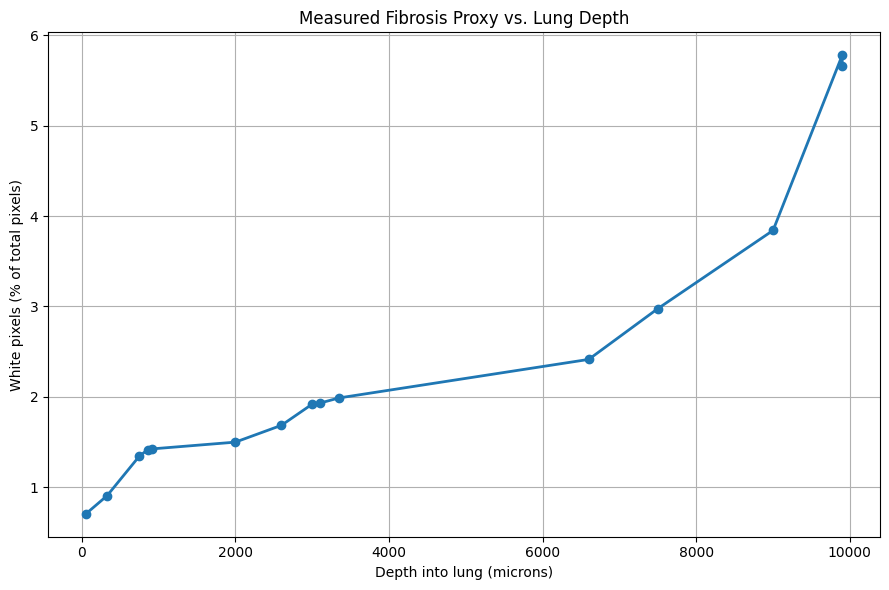

In [3]:
# Now we can also plot the measured data to visualize our results. 
# This will create a plot of the percent of white pixels (which corresponds to fibrosis) at the target depth for each sample.
main.plot_measured_data(analysis_df)

**Figure 1.** Measured fibrosis proxy versus depth into the lung for the 15 selected images. Each point represents one analyzed image, where the fibrosis proxy is defined as the percent of white pixels after binary thresholding. In this selected subset, we measured percent white pixels generally increased with depth, although local variation remained between neighboring sections and between the two measured images at 9900 $\mu\text{m}$.

### 2d. Linear interpolation at 345 $\mu\text{m}$
After generating the measured dataset, we used linear interpolation to estimate the percent white pixels at **345 $\mu\text{m}$**, a depth for which we did not directly use one of our selected images. We used both the built-in `interp1d(..., kind='linear')` approach from lecture and a manual matrix-based linear polynomial calculation following the style of `interpolation_example.py`.

Linear interpolation result:
Target depth: 345.0 microns
SciPy linear interpolation: 0.923238% white pixels
Manual matrix linear interpolation: 0.923238% white pixels
Coefficients [a1, a2]: [0.56384461 0.00104172]

Linear interpolation verification:
manual_linear_value: 0.9232376302991594
numpy_linear_value: 0.9232376302991595
absolute_difference: 1.1102230246251565e-16

Saved linear interpolation plot to: E:\OneDrive - University of Virginia\Will M\Undergraduate Research Courses-Grants\05_Spring_2026\Computational_Biomedical_BME_2315\Module-3-Fibrosis\results\Linear_Interpolation.png


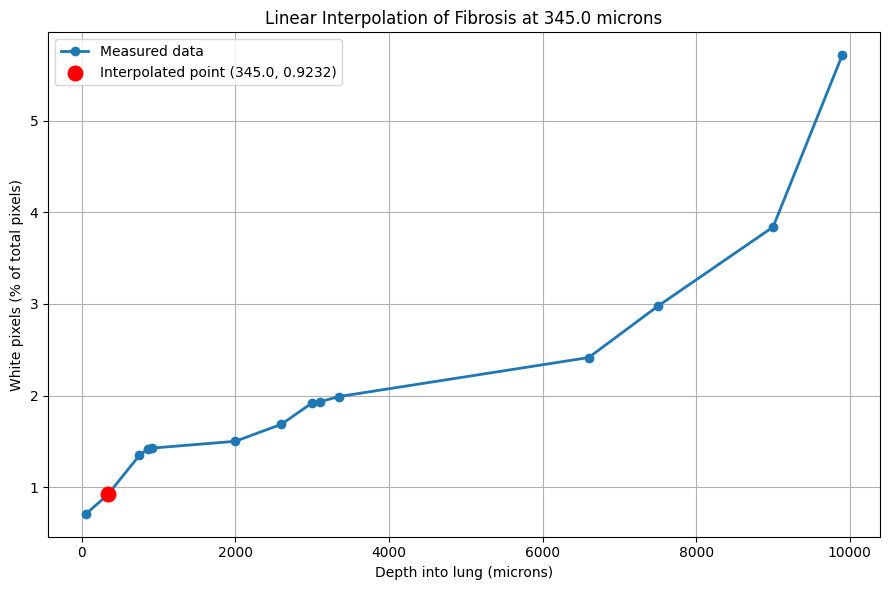

Saved interpolation results to: E:\OneDrive - University of Virginia\Will M\Undergraduate Research Courses-Grants\05_Spring_2026\Computational_Biomedical_BME_2315\Module-3-Fibrosis\results\Interpolation_Results.csv


,method,estimated_percent_white_at_345_um
0,SciPy linear,0.923238
1,Manual matrix linear,0.923238


In [4]:
# Next, we run our linear interpolation analysis to estimate the percent of white pixels at the target depth using both SciPy's interpolation and our manual matrix method. 
linear_result = main.run_linear_interpolation(
    analysis_df=analysis_df,
    target_depth_um=TARGET_DEPTH_UM
)

# We then create a summary DataFrame to display these results side by side.
linear_summary = pd.DataFrame(
    {
        "method": ["SciPy linear", "Manual matrix linear"],
        "estimated_percent_white_at_345_um": [
            linear_result["scipy_interpolated_percent_white"],
            linear_result["manual_interpolated_percent_white"],
        ],
    }
)

# Finally, we display the summary of our linear interpolation results.
display(linear_summary)

Using linear interpolation, the estimated fibrosis proxy at **345 $\mu\text{m}$** was **0.923238% white pixels**. The built-in SciPy linear interpolation and the manual matrix-based linear interpolation produced the same value to the displayed precision, showing that both linear implementations were consistent for this target depth.

### 2e. Quadratic interpolation at 345 $\mu\text{m}$

We next repeated the estimate using quadratic interpolation. This allowed us to compare a higher-order interpolation method to the linear result and to demonstrate a second interpolation approach, as requested in lecture.

Quadratic interpolation result:
Target depth: 345.0 microns
SciPy quadratic interpolation: 0.921540% white pixels
Manual matrix quadratic interpolation: 0.927708% white pixels
Coefficients [a1, a2, a3]: [ 3.81736357e-01  1.83637310e-03 -7.35790932e-07]

Saved quadratic interpolation plot to: E:\OneDrive - University of Virginia\Will M\Undergraduate Research Courses-Grants\05_Spring_2026\Computational_Biomedical_BME_2315\Module-3-Fibrosis\results\Quadratic_Interpolation.png


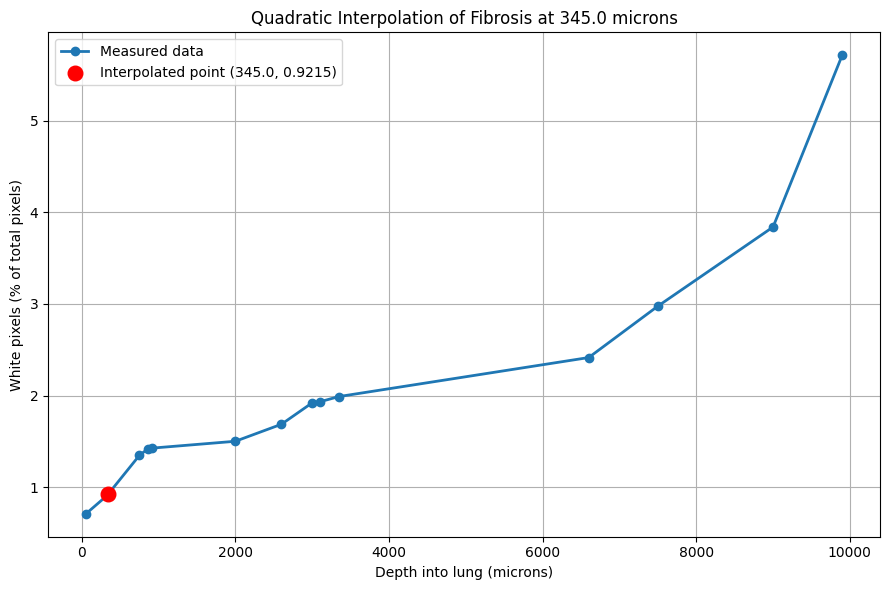

Saved interpolation results to: E:\OneDrive - University of Virginia\Will M\Undergraduate Research Courses-Grants\05_Spring_2026\Computational_Biomedical_BME_2315\Module-3-Fibrosis\results\Interpolation_Results.csv


,method,estimated_percent_white_at_345_um
0,SciPy quadratic,0.921540
1,Manual matrix quadratic,0.927708


In [5]:
# Next, we run our quadratic interpolation analysis to estimate the percent of white pixels at the target depth using both SciPy's interpolation and our manual matrix method.
quadratic_result = main.run_quadratic_interpolation(
    analysis_df=analysis_df,
    target_depth_um=TARGET_DEPTH_UM
)

# We then create a summary DataFrame to display these results side by side.
quadratic_summary = pd.DataFrame(
    {
        "method": ["SciPy quadratic", "Manual matrix quadratic"],
        "estimated_percent_white_at_345_um": [
            quadratic_result["scipy_interpolated_percent_white"],
            quadratic_result["manual_interpolated_percent_white"],
        ],
    }
)

# Finally, we display the summary of our quadratic interpolation results.
display(quadratic_summary)

Using quadratic interpolation, the built-in SciPy method estimated **0.921540% white pixels** at **345 $\mu$m**, while the manual three-point matrix-based quadratic polynomial estimated **0.927708% white pixels**. These values were close but not identical, indicating that the estimated fibrosis proxy at this depth was only mildly sensitive to the interpolation method used.

### 2f. Summary of interpolation estimates

To summarize the interpolation stage, the table below compares the estimates produced at **345 $\mu$m**. Across all methods tested, the predicted fibrosis proxy at this unmeasured depth remained close to **0.92-0.93% white pixels**.

In [6]:
# To compare all our interpolation results together, we can create a combined DataFrame that includes both linear and quadratic interpolation estimates from both methods.
interpolation_comparison_df = pd.DataFrame(
    {
        "method": [
            "SciPy linear",
            "Manual matrix linear",
            "SciPy quadratic",
            "Manual matrix quadratic",
        ],
        "estimated_percent_white_at_345_um": [
            linear_result["scipy_interpolated_percent_white"],
            linear_result["manual_interpolated_percent_white"],
            quadratic_result["scipy_interpolated_percent_white"],
            quadratic_result["manual_interpolated_percent_white"],
        ],
    }
)

# Finally, we display the summary of all our interpolation results together for easy comparison.
display(interpolation_comparison_df)

,method,estimated_percent_white_at_345_um
0,SciPy linear,0.923238
1,Manual matrix linear,0.923238
2,SciPy quadratic,0.921540
3,Manual matrix quadratic,0.927708


Taken together, the interpolation analysis suggests that the predicted fibrosis proxy at **345 $\mu\text{m}$** is consistently just under **1% white pixels**. This interpolation step addresses the central project goal of estimating fibrosis at depths where a direct measurement was not part of the selected image subset.

### 2g. Extra computational benchmark

As an additional computational check, we used the optional runtime benchmark built into `main.py` to estimate how quickly the analysis pipeline could scale to larger image sets. This benchmark was not used to make the biological interpretation, but it helps describe the efficiency of the code implementation.

In [7]:
# Lastly, we can run our full benchmark pipeline to evaluate the performance of our interpolation methods and display the results in a comprehensive DataFrame.
benchmark_df = main.benchmark_pipeline()
display(benchmark_df)

Saved runtime benchmark to: E:\OneDrive - University of Virginia\Will M\Undergraduate Research Courses-Grants\05_Spring_2026\Computational_Biomedical_BME_2315\Module-3-Fibrosis\results\Runtime_Benchmark.csv
Runtime benchmark:
   n_images_tested  repeats  mean_total_seconds  mean_seconds_per_image  \
0               15        5            0.130093                0.008673   

   estimated_seconds_for_10000_images  estimated_minutes_for_10000_images  
0                           86.728867                            1.445481  



,n_images_tested,repeats,mean_total_seconds,mean_seconds_per_image,estimated_seconds_for_10000_images,estimated_minutes_for_10000_images
0,15,5,0.130093,0.008673,86.728867,1.445481


For the selected 15 images, the code required about 0.13 seconds per full benchmark run, corresponding to about 0.009 seconds per image. Based on this timing, the same workflow would be expected to process 10,000 images in roughly 1.4-1.5 minutes on this machine.

### 2h. Verification and Validation Check

Verification checks on the image-analysis table:
                         basename  pixel_sum_matches_total  \
0   MASK_Sk658 Llobe ch010036.jpg                     True   
1   MASK_SK658 Slobe ch010156.jpg                     True   
2   MASK_SK658 Slobe ch010157.jpg                     True   
3   MASK_SK658 Slobe ch010159.jpg                     True   
4   MASK_SK658 Slobe ch010158.jpg                     True   
5   MASK_SK658 Slobe ch010146.jpg                     True   
6   MASK_SK658 Slobe ch010143.jpg                     True   
7   MASK_SK658 Slobe ch010147.jpg                     True   
8   MASK_Sk658 Llobe ch010174.jpg                     True   
9   MASK_SK658 Slobe ch010149.jpg                     True   
10  MASK_Sk658 Llobe ch010034.jpg                     True   
11  MASK_Sk658 Llobe ch010149.jpg                     True   
12  MASK_Sk658 Llobe ch010121.jpg                     True   
13  MASK_SK658 Slobe ch010114.jpg                     True   
14  MASK_SK658 Slobe 

,basename,pixel_sum_matches_total,percent_between_0_and_100
0,MASK_Sk658 Llobe ch010036.jpg,True,True
1,MASK_SK658 Slobe ch010156.jpg,True,True
2,MASK_SK658 Slobe ch010157.jpg,True,True
3,MASK_SK658 Slobe ch010159.jpg,True,True
4,MASK_SK658 Slobe ch010158.jpg,True,True
5,MASK_SK658 Slobe ch010146.jpg,True,True
6,MASK_SK658 Slobe ch010143.jpg,True,True
7,MASK_SK658 Slobe ch010147.jpg,True,True
8,MASK_Sk658 Llobe ch010174.jpg,True,True
9,MASK_SK658 Slobe ch010149.jpg,True,True


Saved interpolation validation table to: E:\OneDrive - University of Virginia\Will M\Undergraduate Research Courses-Grants\05_Spring_2026\Computational_Biomedical_BME_2315\Module-3-Fibrosis\results\Interpolation_Validation.csv
Validation result:
   target_depth_um interpolation_method  predicted_percent_white  \
0       345.000000               linear                 0.923238   

       validation_image_basename  validation_image_depth_um  \
0  mask_sk658 llobe ch010040.jpg                 380.000000   

   measured_percent_white  absolute_error  percent_relative_error  
0                0.999999        0.076761                7.676149  

Saved validation plot to: E:\OneDrive - University of Virginia\Will M\Undergraduate Research Courses-Grants\05_Spring_2026\Computational_Biomedical_BME_2315\Module-3-Fibrosis\results\Interpolation_Validation.png


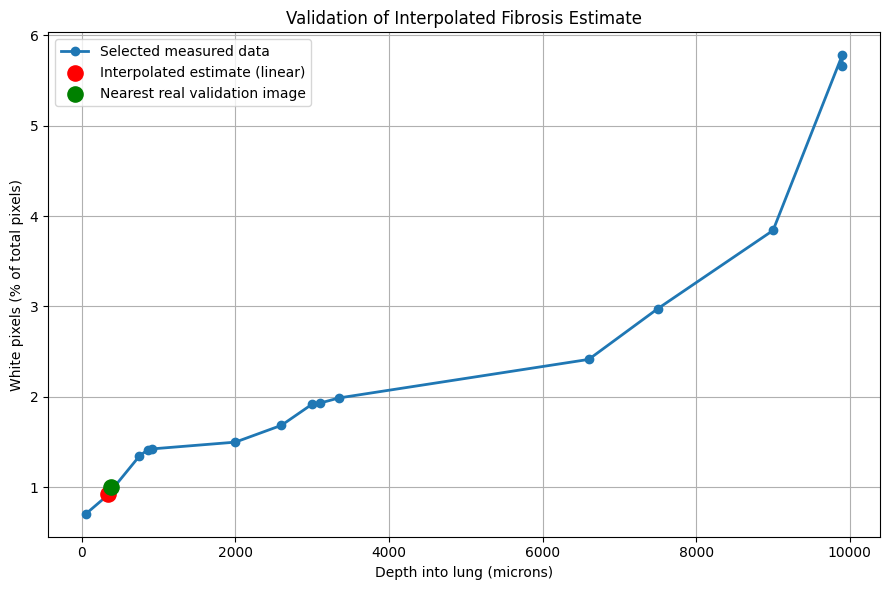

,target_depth_um,interpolation_method,predicted_percent_white,validation_image_basename,validation_image_depth_um,measured_percent_white,absolute_error,percent_relative_error
0,345.000000,linear,0.923238,mask_sk658 llobe ch010040.jpg,380.000000,0.999999,0.076761,7.676149


In [8]:
# Verification checks on the measured image-analysis table
verification_df = main.verify_analysis_table(analysis_df)
display(verification_df)

# Validation of the interpolation estimate against a nearby real image
validation_df = main.run_validation(
    analysis_df=analysis_df,
    target_depth_um=TARGET_DEPTH_UM,
    method="linear"
)
display(validation_df)

Here, we

## Verify and validate your analysis: 

### Verification:

We verified our analysis in a couple of ways. First, we checked the internal consistency of the image-analysis pipeline by confirming that, for every image, the number of white pixels plus the number of black pixels exactly equaled the total number of pixels in that image. We also confirmed that every computed fibrosis representative value fell within the physically meaningful range of 0% to 100% white pixels. In our selected subset, all 15 images passed both checks, which supports that the thresholding and pixel-counting pipeline was implemented correctly by us.

Second, we verified the interpolation calculation itself by comparing the built-in SciPy linear interpolation result to a manual matrix-based linear interpolation following the polynomial method we did on the whiteboard in class. At the target depth of 345 $\mu\text{m}$, both approaches gave the same estimate to displayed precision:

$$
0.923238\% \text{ white pixels}.
$$

The absolute difference between the manual linear interpolation value and NumPy's linear interpolation check was

$$
1.1102230246251565 \times 10^{-16},
$$

which is effectively zero and indicates that the linear interpolation implementation was numerically consistent.

We also compared interpolation approaches more broadly. The four estimates at 345 $\mu\text{m}$ were:

- SciPy linear: **0.923238%**
- Manual matrix linear: **0.923238%**
- SciPy quadratic: **0.921540%**
- Manual matrix quadratic: **0.927708%**

Because all four methods produced values in a narrow range of approximately **0.92-0.93% white pixels**, our estimate at the target depth appears stable and not overly sensitive to the interpolation method chosen.

### Validation:

To validate our interpolation result, we compared the estimated fibrosis representative at 345 $\mu\text{m}$ to a real image from the full dataset located near that same depth. Using the linear interpolation result from our selected subset, the predicted fibrosis representative at 345 $\mu\text{m}$ was

$$
0.923238\% \text{ white pixels}.
$$

The nearest real validation image outside the selected subset was `mask_sk658 llobe ch010040.jpg`, obtained at a depth of **380 $\mu\text{m}$**. When we analyzed that actual image, we measured

$$
0.999999\% \text{ white pixels}.
$$

The absolute error between the interpolated prediction and the measured validation image was therefore

$$
|0.999999 - 0.923238| = 0.076761 \text{ percentage points},
$$

and the percent relative error was

$$
\frac{0.076761}{0.999999} \times 100\% \approx 7.676149\%.
$$

This is a relatively small error, especially given that the validation image was not taken at exactly 345 $\mu\text{m}$ but rather at 380 $\mu\text{m}$. This comparison supports that our interpolation-based estimate is reasonable and that the pipeline can provide a useful approximation of fibrosis severity at depths where a direct image measurement is not available.

Overall, our verification checks support that the code is internally consistent, and our validation step supports that the interpolation result is biologically plausible when compared to a nearby real measurement.

## Conclusions and Ethical Implications: 

### Conclusions:

Our analysis suggests that the fibrosis representative, measured as percent white pixels in black-and-white lung sections, generally increased with depth in our selected subset of images. In the measured dataset, the fibrosis representative ranged from **0.707555% white pixels** at **55 $\mu\text{m}$** to approximately **5.66-5.78% white pixels** at **9900 $\mu\text{m}$**. Although there was some local variation between nearby sections, the overall trend indicates that fibrosis was not distributed uniformly throughout the sampled depth range.

Using interpolation, we estimated the fibrosis representative at a depth of **345 $\mu\text{m}$**, where we did not directly include one of our selected images. All interpolation methods produced a very similar result, with predicted values ranging from approximately **0.921540%** to **0.927708% white pixels**. Taken together, these results suggest that the fibrosis burden at 345 $\mu\text{m}$ is just under **1% white pixels**.

In the context of our project goal, these findings support the idea that a computational image-analysis pipeline can be used not only to quantify fibrosis at measured biopsy depths, but also to estimate fibrosis at nearby unmeasured depths. This is useful because, in a real biopsy setting, it is not practical to collect tissue at every possible depth throughout the lung. A depth-aware interpolation framework can therefore help predict how fibrosis changes through tissue and can support the design of a biopsy device that targets regions more precisely.

Our results also suggest an important design implication for such a device: because fibrosis appears to vary with depth rather than remaining constant, a next-generation biopsy tool would benefit from accurate depth control and depth tracking. If fibrosis severity changes meaningfully over short distances, then sampling from the wrong depth could underrepresent or overrepresent the true extent of disease.

### Ethical Implications:

Although this analysis was useful, the predictions generated by the interpolation model should not be treated as exact science or truth. Interpolation is an estimate based on neighboring data points, and real tissue is heterogeneous. A predicted fibrosis value at an unmeasured depth could differ from the true biological value if the tissue changes abruptly or if the selected images do not fully represent the surrounding lung region. For this reason, interpolation should support medical decision-making, not replace direct measurement, pathology review, or clinical judgment.

There are also ethical considerations related to translation from a mouse model to human disease. Our dataset came from a fibrotic mouse lung (commonly used in research here at UVA), which is a valuable research model but not a perfect representation of human lung fibrosis. A device or algorithm developed from this kind of dataset must therefore be validated carefully before being applied clinically. Overgeneralizing from animal data to human patients could lead to misleading conclusions or inappropriate clinical decisions.

Another ethical issue is sampling bias. If a biopsy device samples tissue from only one location or one depth, it may miss other regions with different fibrosis severity. Since our results suggest that fibrosis is depth-dependent and locally variable, inaccurate or poorly targeted sampling could cause clinicians to underestimate disease severity in one patient or overestimate it in another. This reinforces the importance of precise device placement and transparent communication about model uncertainty to the stakeholders involved (patients).

Finally, if depth-specific biopsy technologies become clinically useful, they should be implemented in a way that promotes equitable access for everyone. Advanced image-guided or depth-guided biopsy tools could improve diagnosis, but only if they are available to a broad range of patients rather than being limited to well-resourced medical centers. Ethical development of such technology should therefore consider not only technical accuracy, but also safety, transparency, and fairness in who benefits from the device. This is all aligned with the goal of providing quality medical science to ALL of those who need it.

## Limitations and Future Work: 
*Describe the limitations of your project. If you had more time to work on this, what would you do to explore further or refine your analysis?*

## Notes:

* **Completed:**
    * Data and Disease Background: Roy

    * Data Analysis: Will and Roy

    * Verification/Validation: Will
    
    * Conclusions/Ethics: Will

    * Limitations/Future Work: Roy


* **To Do:**
    * Nothing at this time.


* **Questions/Concerns:**
    * Nothing at this time.


* **References:**
    * [1]




* **AI Statement:**
    * External use of LLMs was utilized on a case-by-case basis, often for initial source discovery + inspiration and code debugging. GitHub Copilot (which we students have a free trial) was especially helpful with providing 'Inline Suggestions' for shortening time with boilerplate code and repetitive function naming. This was particularly helpful for implementing LaTeX format into our markdown segments to that we can easily see the equations being used in a clear sense. However, the final code structure, modeling choices, and interpretations were based on the course lectures, GitHub materials, and provided resources, with all final analysis completed by our team. 



